# **Length of Stay Prediction**

### Notebook Overview

The notebook LOS.ipynb focuses on predicting Length of Stay (LOS) in the ICU using machine learning models. It utilizes data from the MIMIC-III clinical database and applies various feature engineering, preprocessing, and model training techniques.

1. **Load Data** – Reads and processes datasets from MIMIC-III.

2. **Feature Engineering**:

   - **ADMISSIONS** Table

   - **DIAGNOSES_ICD** Table

   - **PATIENTS** Table

   - **ICUSTAYS** Table

3. **Data Cleaning and Splitting** – Prepares and partitions data for training and evaluation.

4. **Machine Learning Models** – Trains multiple models to predict LOS.

5. **Model Fine-tuning** – Hyperparameter tuning to improve model performance.

6. **Evaluation** – Assesses models using performance metrics.

### Key Techniques and Libraries

- **Data Handling**: `pandas`, `numpy`

- **Visualization**: `matplotlib`, `seaborn`

- **Machine Learning**: `sklearn` (Linear Regression, Random Forest, Gradient Boosting, SVM, KNN, Decision Tree, SGDRegressor)

- **Hyperparameter Tuning**: `GridSearchCV`

- **Metrics**: `r2_score`, `mean_squared_error`

The notebook is structured to analyze ICU patient data and apply machine learning techniques to predict **Length of Stay (LOS)** based on clinical variables.

In [1]:
# Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import GridSearchCV

In [2]:
!pip install --quiet google-cloud-bigquery

# Import libraries
from google.cloud import bigquery
from google.colab import auth

# Authenticate your Google account
auth.authenticate_user()

# Set up BigQuery client (use your GCP project ID)
project_id = 'akashapiplayground'  # Replace with your actual project ID
client = bigquery.Client(project=project_id)

**Load Data**

In [ ]:
# from google.colab import files
# uploaded = files.upload()

In [6]:

query = """

  SELECT *
  FROM physionet-data.mimiciii_clinical.admissions
  """

query_job = client.query(query)
df = query_job.to_dataframe()

In [7]:

query = """

  SELECT *
  FROM physionet-data.mimiciii_clinical.patients
  """

query_job = client.query(query)
df_pat = query_job.to_dataframe()

In [8]:

query = """

  SELECT *
  FROM physionet-data.mimiciii_clinical.diagnoses_icd
  """

query_job = client.query(query)
df_diagcode = query_job.to_dataframe()

In [9]:

query = """

  SELECT *
  FROM physionet-data.mimiciii_clinical.icustays
  """

query_job = client.query(query)
df_icu = query_job.to_dataframe()

In [ ]:
# base_path_mimic = 'PATH_TO_MIMIC'

# # Add'.gz' if you uploaded .gz file (or else omit)
# path_admissions = os.path.join(base_path_mimic, 'ADMISSIONS.csv.gz')
# path_patients = os.path.join(base_path_mimic, 'PATIENTS.csv.gz')
# path_diagnoses = os.path.join(base_path_mimic, 'DIAGNOSES_ICD.csv.gz')
# path_icustays = os.path.join(base_path_mimic, 'ICUSTAYS.csv.gz')

# # Primary Admissions information
# df = pd.read_csv(path_admissions)

# # Patient specific info such as gender
# df_pat = pd.read_csv(path_patients)

# # Diagnosis for each admission to hospital
# df_diagcode = pd.read_csv(path_diagnoses)

# # Intensive Care Unit (ICU) for each admission to hospital
# df_icu = pd.read_csv(path_icustays)

**Feature Engineering: ADMISSIONS Table**

In [10]:
list(df)

['ROW_ID',
 'SUBJECT_ID',
 'HADM_ID',
 'ADMITTIME',
 'DISCHTIME',
 'DEATHTIME',
 'ADMISSION_TYPE',
 'ADMISSION_LOCATION',
 'DISCHARGE_LOCATION',
 'INSURANCE',
 'LANGUAGE',
 'RELIGION',
 'MARITAL_STATUS',
 'ETHNICITY',
 'EDREGTIME',
 'EDOUTTIME',
 'DIAGNOSIS',
 'HOSPITAL_EXPIRE_FLAG',
 'HAS_CHARTEVENTS_DATA']

In [11]:
df["HOSPITAL_EXPIRE_FLAG"].value_counts()

,count
HOSPITAL_EXPIRE_FLAG,
0,53122
1,5854


In [13]:
print('Dataset has {} number of unique admission events.'.format(df['HADM_ID'].nunique()))
print('Dataset has {} number of total admission events.'.format(len(df)))
print('Dataset has {} number of unique patients.'.format(df['SUBJECT_ID'].nunique()))

Dataset has 58976 number of unique admission events.
Dataset has 58976 number of total admission events.
Dataset has 46520 number of unique patients.


In [14]:
df.head()

,ROW_ID,SUBJECT_ID,HADM_ID,ADMITTIME,DISCHTIME,DEATHTIME,ADMISSION_TYPE,ADMISSION_LOCATION,DISCHARGE_LOCATION,INSURANCE,LANGUAGE,RELIGION,MARITAL_STATUS,ETHNICITY,EDREGTIME,EDOUTTIME,DIAGNOSIS,HOSPITAL_EXPIRE_FLAG,HAS_CHARTEVENTS_DATA
0,3757,3115,134067,2139-02-13 03:11:00,2139-02-20 07:33:00,NaT,EMERGENCY,EMERGENCY ROOM ADMIT,SNF,Medicare,None,None,None,WHITE,2139-02-13 00:02:00,2139-02-13 03:22:00,STAB WOUND,0,1
1,8689,7124,109129,2188-07-11 00:58:00,2188-08-01 12:04:00,NaT,EMERGENCY,EMERGENCY ROOM ADMIT,SNF,Medicare,None,None,None,WHITE,2188-07-10 14:17:00,2188-07-11 01:52:00,PENILE LACERATION-CELLULITIS,0,1
2,12652,10348,121510,2133-04-16 21:12:00,2133-04-23 15:52:00,NaT,EMERGENCY,EMERGENCY ROOM ADMIT,SNF,Medicare,None,None,None,UNKNOWN/NOT SPECIFIED,2133-04-16 19:22:00,2133-04-16 22:17:00,STATUS EPILEPTICUS,0,1
3,11501,9396,106469,2109-02-16 23:14:00,2109-02-23 12:01:00,NaT,EMERGENCY,EMERGENCY ROOM ADMIT,SNF,Medicare,None,None,None,WHITE,2109-02-16 20:58:00,2109-02-16 23:42:00,SUBDURAL HEMATOMA,0,1
4,11419,9333,133732,2167-10-06 18:35:00,2167-10-16 13:13:00,NaT,URGENT,TRANSFER FROM HOSP/EXTRAM,SNF,Private,None,None,None,UNKNOWN/NOT SPECIFIED,NaT,NaT,CORONARY ARTERY DISEASE,0,1


In [15]:
# Convert admission and discharge times to datatime type
df['ADMITTIME'] = pd.to_datetime(df['ADMITTIME'])
df['DISCHTIME'] = pd.to_datetime(df['DISCHTIME'])

# Convert timedelta type into float 'days', 86400 seconds in a day
df['LOS'] = (df['DISCHTIME'] - df['ADMITTIME']).dt.total_seconds()/86400

In [16]:
# Verify
df[['ADMITTIME', 'DISCHTIME', 'LOS']].head()

,ADMITTIME,DISCHTIME,LOS
0,2139-02-13 03:11:00,2139-02-20 07:33:00,7.181944
1,2188-07-11 00:58:00,2188-08-01 12:04:00,21.462500
2,2133-04-16 21:12:00,2133-04-23 15:52:00,6.777778
3,2109-02-16 23:14:00,2109-02-23 12:01:00,6.532639
4,2167-10-06 18:35:00,2167-10-16 13:13:00,9.776389


In [17]:
df['LOS'].describe()

,LOS
count,58976.000000
mean,10.133916
std,12.456682
min,-0.945139
25%,3.743750
50%,6.467014
75%,11.795139
max,294.660417


In [18]:
# Look at what is happening with negative LOS values
df[df['LOS'] < 0]

,ROW_ID,SUBJECT_ID,HADM_ID,ADMITTIME,DISCHTIME,DEATHTIME,ADMISSION_TYPE,ADMISSION_LOCATION,DISCHARGE_LOCATION,INSURANCE,LANGUAGE,RELIGION,MARITAL_STATUS,ETHNICITY,EDREGTIME,EDOUTTIME,DIAGNOSIS,HOSPITAL_EXPIRE_FLAG,HAS_CHARTEVENTS_DATA,LOS
77,14636,11903,137399,2157-08-25 19:50:00,2157-08-25 07:26:00,2157-08-25 07:26:00,EMERGENCY,EMERGENCY ROOM ADMIT,DEAD/EXPIRED,Private,None,None,None,UNKNOWN/NOT SPECIFIED,2157-08-25 18:12:00,2157-08-25 19:44:00,S/P FALL,1,1,-0.516667
89,22651,18567,143379,2133-02-08 15:24:00,2133-02-08 07:17:00,2133-02-08 07:17:00,EMERGENCY,EMERGENCY ROOM ADMIT,DEAD/EXPIRED,Private,None,None,None,OTHER,2133-02-08 14:10:00,2133-02-08 15:26:00,INTERCRANIAL BLEED,1,1,-0.338194
91,24842,20349,131432,2183-12-10 16:49:00,2183-12-10 07:48:00,2183-12-10 07:48:00,EMERGENCY,EMERGENCY ROOM ADMIT,DEAD/EXPIRED,Private,None,None,None,WHITE,2183-12-10 14:22:00,2183-12-10 17:48:00,MVA,1,1,-0.375694
109,10704,8754,171918,2169-05-15 16:58:00,2169-05-15 02:03:00,2169-05-15 02:03:00,EMERGENCY,PHYS REFERRAL/NORMAL DELI,DEAD/EXPIRED,Medicare,None,None,None,UNKNOWN/NOT SPECIFIED,NaT,NaT,S/P NON Q MI\CATH,1,0,-0.621528
123,25961,21272,156385,2162-09-25 07:36:00,2162-09-25 01:23:00,2162-09-25 01:23:00,EMERGENCY,TRANSFER FROM SKILLED NUR,DEAD/EXPIRED,Medicare,None,None,None,OTHER,2162-09-24 20:46:00,2162-09-25 07:48:00,R/O UROSEPSIS,1,1,-0.259028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54245,57376,95022,192239,2172-11-27 17:30:00,2172-11-27 00:00:00,2172-11-27 00:00:00,EMERGENCY,CLINIC REFERRAL/PREMATURE,DEAD/EXPIRED,Medicare,ENGL,PROTESTANT QUAKER,WIDOWED,WHITE,2172-11-27 14:25:00,2172-11-27 19:09:00,INTRACRANIAL HEMORRHAGE,1,1,-0.729167
55821,58720,99207,191004,2143-07-06 19:59:00,2143-07-06 12:00:00,2143-07-06 12:00:00,EMERGENCY,EMERGENCY ROOM ADMIT,DEAD/EXPIRED,Medicaid,ENGL,CATHOLIC,DIVORCED,WHITE,2143-07-06 19:30:00,2143-07-06 20:05:00,GSW L. CHEST WALL & ABDOMEN,1,1,-0.332639
57720,28847,23650,102161,2115-03-29 19:59:00,2115-03-29 12:00:00,2115-03-29 12:00:00,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,DEAD/EXPIRED,Medicare,None,PROTESTANT QUAKER,DIVORCED,WHITE,NaT,NaT,PULMONARY EMBOLIS,1,1,-0.332639
58701,22633,18552,120398,2161-09-11 18:40:00,2161-09-11 12:00:00,2161-09-11 12:00:00,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,DEAD/EXPIRED,Medicare,SPAN,CATHOLIC,UNKNOWN (DEFAULT),UNKNOWN/NOT SPECIFIED,NaT,NaT,FEVER;ACUTE RESPIRATORY FAILURE,1,1,-0.277778


In [19]:
# Drop rows with negative LOS, usually related to a time of death before admission
df['LOS'][df['LOS'] > 0].describe()

,LOS
count,58878.000000
mean,10.151266
std,12.459774
min,0.001389
25%,3.755556
50%,6.489583
75%,11.805556
max,294.660417


In [20]:
# Drop LOS < 0
df = df[df['LOS'] > 0]

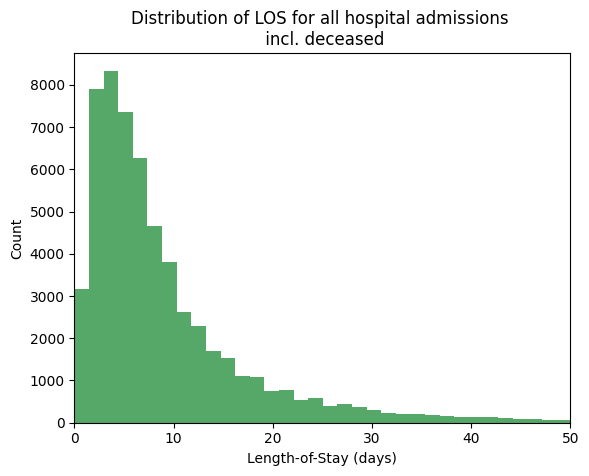

In [21]:
# Plot LOS Distribution
plt.hist(df['LOS'], bins=200, color = '#55a868')
plt.xlim(0, 50)
plt.title('Distribution of LOS for all hospital admissions \n incl. deceased')
plt.ylabel('Count')
plt.xlabel('Length-of-Stay (days)')
plt.tick_params(top=False, right=False)
plt.show();

In [22]:
# Pre-emptively drop some columns that I don't need anymore
df.drop(columns=['DISCHTIME', 'ROW_ID',
                'EDREGTIME', 'EDOUTTIME', 'HOSPITAL_EXPIRE_FLAG',
                'HAS_CHARTEVENTS_DATA'], inplace=True)

In [23]:
# Mark admissions where patients died in boolean column
df['DECEASED'] = df['DEATHTIME'].notnull().map({True:1, False:0})

In [24]:
print("{} of {} patients died in the hospital".format(df['DECEASED'].sum(),
                                                     df['SUBJECT_ID'].nunique()))

5774 of 46445 patients died in the hospital


In [25]:
df.head()


,SUBJECT_ID,HADM_ID,ADMITTIME,DEATHTIME,ADMISSION_TYPE,ADMISSION_LOCATION,DISCHARGE_LOCATION,INSURANCE,LANGUAGE,RELIGION,MARITAL_STATUS,ETHNICITY,DIAGNOSIS,LOS,DECEASED
0,3115,134067,2139-02-13 03:11:00,NaT,EMERGENCY,EMERGENCY ROOM ADMIT,SNF,Medicare,None,None,None,WHITE,STAB WOUND,7.181944,0
1,7124,109129,2188-07-11 00:58:00,NaT,EMERGENCY,EMERGENCY ROOM ADMIT,SNF,Medicare,None,None,None,WHITE,PENILE LACERATION-CELLULITIS,21.462500,0
2,10348,121510,2133-04-16 21:12:00,NaT,EMERGENCY,EMERGENCY ROOM ADMIT,SNF,Medicare,None,None,None,UNKNOWN/NOT SPECIFIED,STATUS EPILEPTICUS,6.777778,0
3,9396,106469,2109-02-16 23:14:00,NaT,EMERGENCY,EMERGENCY ROOM ADMIT,SNF,Medicare,None,None,None,WHITE,SUBDURAL HEMATOMA,6.532639,0
4,9333,133732,2167-10-06 18:35:00,NaT,URGENT,TRANSFER FROM HOSP/EXTRAM,SNF,Private,None,None,None,UNKNOWN/NOT SPECIFIED,CORONARY ARTERY DISEASE,9.776389,0


In [26]:
df['DECEASED'][df['DECEASED']== 1].describe()

,DECEASED
count,5774.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


In [27]:
df[df['DECEASED']==1].head()


,SUBJECT_ID,HADM_ID,ADMITTIME,DEATHTIME,ADMISSION_TYPE,ADMISSION_LOCATION,DISCHARGE_LOCATION,INSURANCE,LANGUAGE,RELIGION,MARITAL_STATUS,ETHNICITY,DIAGNOSIS,LOS,DECEASED
70,2261,124642,2119-09-09 08:25:00,2119-09-13 04:35:00,EMERGENCY,EMERGENCY ROOM ADMIT,DEAD/EXPIRED,Medicare,None,None,None,WHITE,ALLERGIC REACTION/LABILE HTN,3.840278,1
71,7157,189452,2137-12-21 12:56:00,2137-12-22 04:20:00,EMERGENCY,EMERGENCY ROOM ADMIT,DEAD/EXPIRED,Private,None,None,None,UNKNOWN/NOT SPECIFIED,S/P FALL,0.641667,1
72,8239,156930,2169-01-26 18:15:00,2169-01-27 02:20:00,EMERGENCY,EMERGENCY ROOM ADMIT,DEAD/EXPIRED,Medicare,None,None,None,UNKNOWN/NOT SPECIFIED,TRAUMA,0.336806,1
73,6825,138726,2181-03-13 20:09:00,2181-03-18 20:03:00,EMERGENCY,EMERGENCY ROOM ADMIT,DEAD/EXPIRED,Medicare,None,None,None,WHITE,ALTERED MENTAL STATUS,4.995833,1
74,11999,144909,2108-08-09 10:35:00,2108-08-11 04:51:00,EMERGENCY,EMERGENCY ROOM ADMIT,DEAD/EXPIRED,Private,None,None,None,WHITE,MULTIPLE GUNSHOT WOUNDS,1.761111,1


In [28]:
# Look at statistics less admissions resulting in death
df['LOS'].loc[df['DECEASED'] == 0].describe()

,LOS
count,53104.000000
mean,10.138174
std,12.284461
min,0.014583
25%,3.866667
50%,6.565972
75%,11.711632
max,294.660417


In [29]:
# Hospital LOS metrics for later comparison
actual_mean_los = df['LOS'].loc[df['DECEASED'] == 0].mean()
actual_median_los = df['LOS'].loc[df['DECEASED'] == 0].median()

print(actual_mean_los)
print(actual_median_los)

10.138173704219811
6.565972222222222


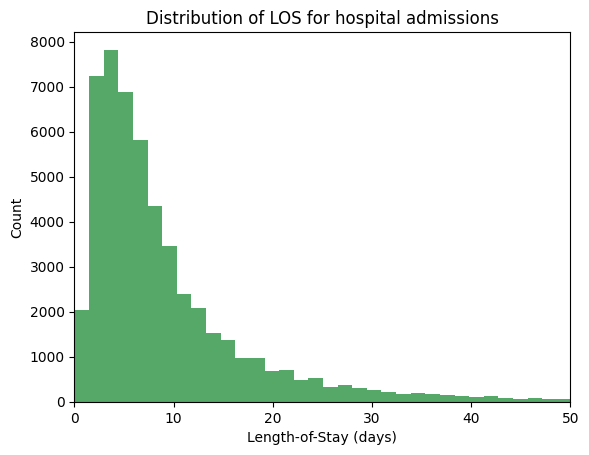

In [30]:
plt.hist(df['LOS'].loc[df['DECEASED'] == 0], bins=200, color = '#55a868')
plt.xlim(0, 50)
plt.title('Distribution of LOS for hospital admissions')
plt.ylabel('Count')
plt.xlabel('Length-of-Stay (days)')
plt.tick_params(top=False, right=False)
plt.show();

In [31]:
df['ETHNICITY'].value_counts()

,count
ETHNICITY,
WHITE,40939
BLACK/AFRICAN AMERICAN,5434
UNKNOWN/NOT SPECIFIED,4502
HISPANIC OR LATINO,1693
ASIAN,1508
OTHER,1507
UNABLE TO OBTAIN,809
PATIENT DECLINED TO ANSWER,559
ASIAN - CHINESE,277


In [32]:
# Compress the number of ethnicity categories
regex_to_replace = {
    r'^ASIAN\D*':    'ASIAN',
    r'^WHITE\D*':    'WHITE',
    r'^HISPANIC\D*': 'HISPANIC/LATINO',
    r'^BLACK\D*':    'BLACK/AFRICAN AMERICAN',
}

df.replace({'ETHNICITY': regex_to_replace}, inplace=True)

# Compress the number of other/unknown ethnicity categories
replace_unknowns = [
    'UNABLE TO OBTAIN',
    'OTHER',
    'PATIENT DECLINED TO ANSWER',
    'UNKNOWN/NOT SPECIFIED'
]

df.replace({'ETHNICITY': replace_unknowns}, 'OTHER/UNKNOWN', inplace=True)

# Replace all other ethnicities with 'OTHER/UNKNOWN' to get get the top 5 most frequent ethnicities
n_top_ethnicities = 5
df.loc[~df['ETHNICITY'].isin(df['ETHNICITY'].value_counts().nlargest(n_top_ethnicities).index.tolist()), 'ETHNICITY'] = 'OTHER/UNKNOWN'

df['ETHNICITY'].value_counts()

,count
ETHNICITY,
WHITE,40939
OTHER/UNKNOWN,9304
BLACK/AFRICAN AMERICAN,5434
HISPANIC OR LATINO,1693
ASIAN,1508


/tmp/ipython-input-33-1364745201.py:36: MatplotlibDeprecationWarning: Passing the notch parameter of boxplot() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  ax.boxplot(hist_data, 0, '', vert=False)


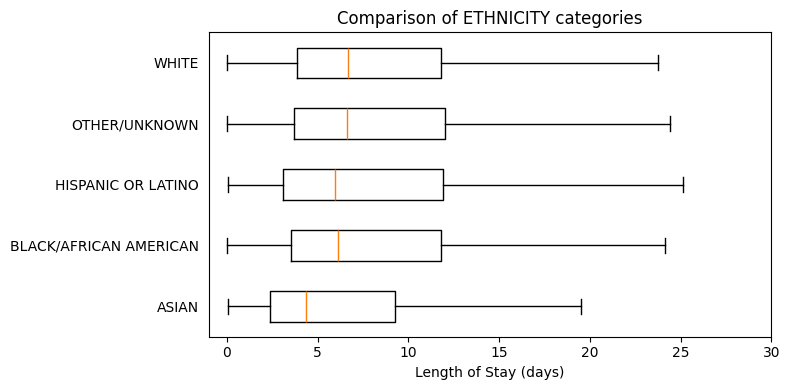

In [33]:
# Re-usable plotting function
def plot_los_groupby(variable, size=(7,4)):
    '''
    Plot Median LOS by df categorical series name
    '''
    results = df[[variable, 'LOS']].groupby(variable).median().reset_index()
    values = list(results['LOS'].values)
    labels = list(results[variable].values)

    fig, ax = plt.subplots(figsize=size)
    ind = range(len(results))
    ax.barh(ind, values, align='center', height=0.6, color = '#55a868', alpha=0.8)
    ax.set_yticks(ind)
    ax.set_yticklabels(labels)
    ax.set_xlabel('Median Length of Stay (days)')
    ax.tick_params(left=False, top=False, right=False)
    ax.set_title('Comparison of {} labels'.format(variable))

    plt.tight_layout()
    plt.show();

# Re-usable boxplot function
def boxplot_los_groupby(variable, los_range=(-1, 30), size=(8,4)):
    '''
    Boxplot of LOS by df categorical series name
    '''
    results = df[[variable, 'LOS']].groupby(variable).median().reset_index()

    categories = results[variable].values.tolist()

    hist_data = []
    for cat in categories:
        hist_data.append(df['LOS'].loc[df[variable]==cat].values)

    fig, ax = plt.subplots(figsize=size)
    ax.boxplot(hist_data, 0, '', vert=False)
    ax.set_xlim(los_range)
    ax.set_yticklabels(categories)
    ax.set_xlabel('Length of Stay (days)')
    ax.tick_params(left=False, right=False)
    ax.set_title('Comparison of {} categories'.format(variable))
    plt.tight_layout()
    plt.show();

boxplot_los_groupby('ETHNICITY', los_range=(-1, 30))

In [34]:
df['RELIGION'].value_counts()

,count
RELIGION,
CATHOLIC,20580
NOT SPECIFIED,11738
UNOBTAINABLE,8242
PROTESTANT QUAKER,7121
JEWISH,5307
OTHER,2695
EPISCOPALIAN,771
GREEK ORTHODOX,459
CHRISTIAN SCIENTIST,429


/tmp/ipython-input-33-1364745201.py:36: MatplotlibDeprecationWarning: Passing the notch parameter of boxplot() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  ax.boxplot(hist_data, 0, '', vert=False)


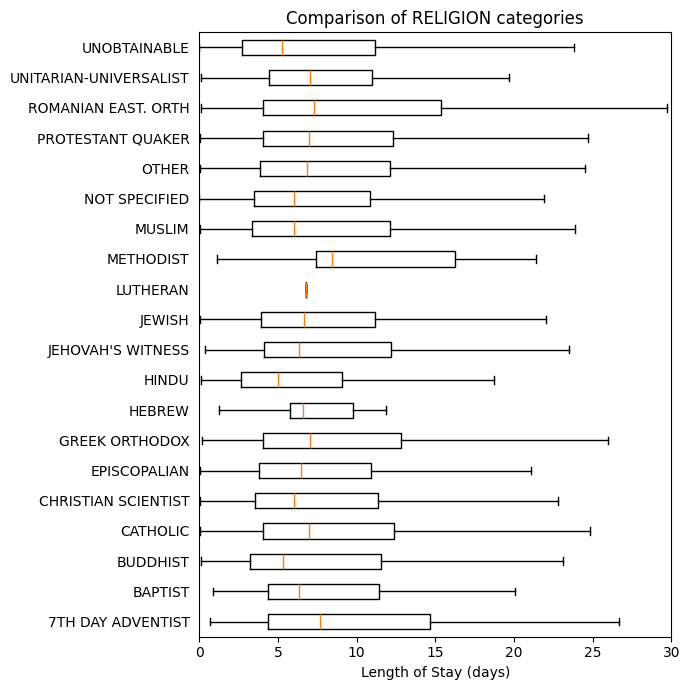

In [35]:
boxplot_los_groupby('RELIGION', los_range=(0, 30), size=(7, 7))

In [36]:
# Reduce categories to terms of religious or not
# I tested with and without category reduction, with little change in R2 score
df.loc[~df['RELIGION'].isin(['RELIGIOUS', 'NOT SPECIFIED', 'UNOBATINABLE']), 'RELIGION'] = 'NOT RELIGIOUS'

print(df['RELIGION'].value_counts(), '\n')
print('Proportion')
print('Relgious:      ', df['RELIGION'].value_counts().iloc[0] / len(df['RELIGION']))
print('Not Religious:  ', df['RELIGION'].value_counts().iloc[1] / len(df['RELIGION']))

RELIGION
NOT RELIGIOUS    47140
NOT SPECIFIED    11738
Name: count, dtype: int64 

Proportion
Relgious:       0.8006386086483915
Not Religious:   0.1993613913516084


In [37]:
df.head()


,SUBJECT_ID,HADM_ID,ADMITTIME,DEATHTIME,ADMISSION_TYPE,ADMISSION_LOCATION,DISCHARGE_LOCATION,INSURANCE,LANGUAGE,RELIGION,MARITAL_STATUS,ETHNICITY,DIAGNOSIS,LOS,DECEASED
0,3115,134067,2139-02-13 03:11:00,NaT,EMERGENCY,EMERGENCY ROOM ADMIT,SNF,Medicare,None,NOT RELIGIOUS,None,WHITE,STAB WOUND,7.181944,0
1,7124,109129,2188-07-11 00:58:00,NaT,EMERGENCY,EMERGENCY ROOM ADMIT,SNF,Medicare,None,NOT RELIGIOUS,None,WHITE,PENILE LACERATION-CELLULITIS,21.462500,0
2,10348,121510,2133-04-16 21:12:00,NaT,EMERGENCY,EMERGENCY ROOM ADMIT,SNF,Medicare,None,NOT RELIGIOUS,None,OTHER/UNKNOWN,STATUS EPILEPTICUS,6.777778,0
3,9396,106469,2109-02-16 23:14:00,NaT,EMERGENCY,EMERGENCY ROOM ADMIT,SNF,Medicare,None,NOT RELIGIOUS,None,WHITE,SUBDURAL HEMATOMA,6.532639,0
4,9333,133732,2167-10-06 18:35:00,NaT,URGENT,TRANSFER FROM HOSP/EXTRAM,SNF,Private,None,NOT RELIGIOUS,None,OTHER/UNKNOWN,CORONARY ARTERY DISEASE,9.776389,0


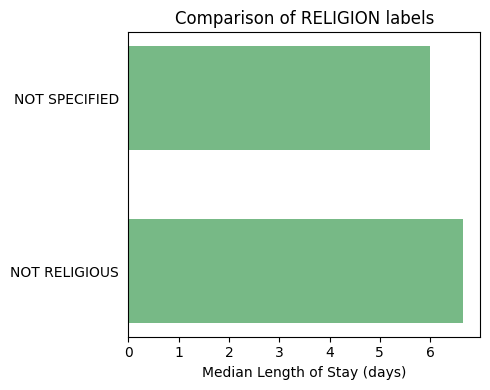

In [38]:
# Look at median LOS for groups
plot_los_groupby('RELIGION', size=(5,4))

In [39]:
df['ADMISSION_TYPE'].value_counts()

,count
ADMISSION_TYPE,
EMERGENCY,41989
NEWBORN,7854
ELECTIVE,7702
URGENT,1333


/tmp/ipython-input-33-1364745201.py:36: MatplotlibDeprecationWarning: Passing the notch parameter of boxplot() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  ax.boxplot(hist_data, 0, '', vert=False)


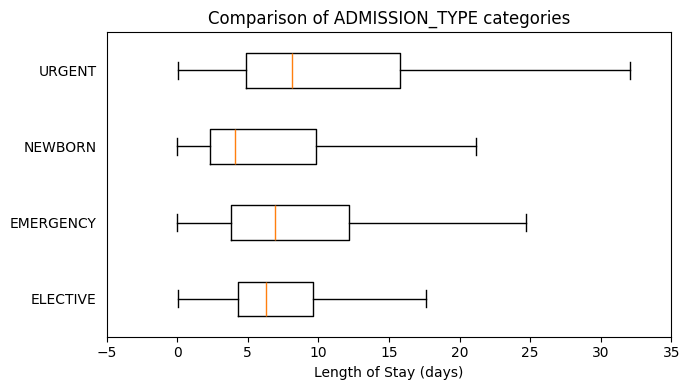

In [40]:
boxplot_los_groupby('ADMISSION_TYPE', los_range=(-5, 35), size=(7, 4))

In [ ]:
df['INSURANCE'].value_counts()

INSURANCE
Medicare      28174
Private       22542
Medicaid       5778
Government     1781
Self Pay        603
Name: count, dtype: int64

/tmp/ipython-input-33-1364745201.py:36: MatplotlibDeprecationWarning: Passing the notch parameter of boxplot() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  ax.boxplot(hist_data, 0, '', vert=False)


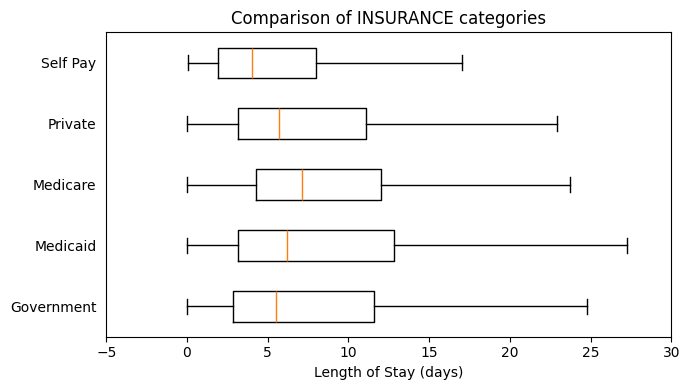

In [41]:
boxplot_los_groupby('INSURANCE', los_range=(-5, 30), size=(7, 4))

In [42]:
df['MARITAL_STATUS'].value_counts(dropna=False)

,count
MARITAL_STATUS,
MARRIED,24199
SINGLE,13238
None,10097
WIDOWED,7204
DIVORCED,3211
SEPARATED,571
UNKNOWN (DEFAULT),343
LIFE PARTNER,15


In [43]:
# Fix NaNs and file under 'UNKNOWN'
df['MARITAL_STATUS'] = df['MARITAL_STATUS'].fillna('UNKNOWN (DEFAULT)')
df['MARITAL_STATUS'].value_counts(dropna=False)

,count
MARITAL_STATUS,
MARRIED,24199
SINGLE,13238
UNKNOWN (DEFAULT),10440
WIDOWED,7204
DIVORCED,3211
SEPARATED,571
LIFE PARTNER,15


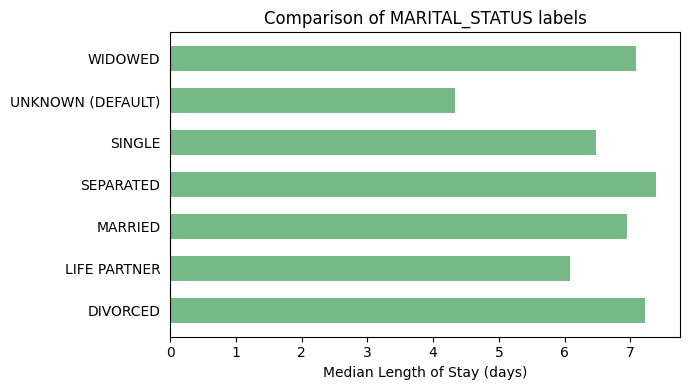

In [44]:
plot_los_groupby('MARITAL_STATUS')

/tmp/ipython-input-33-1364745201.py:36: MatplotlibDeprecationWarning: Passing the notch parameter of boxplot() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  ax.boxplot(hist_data, 0, '', vert=False)


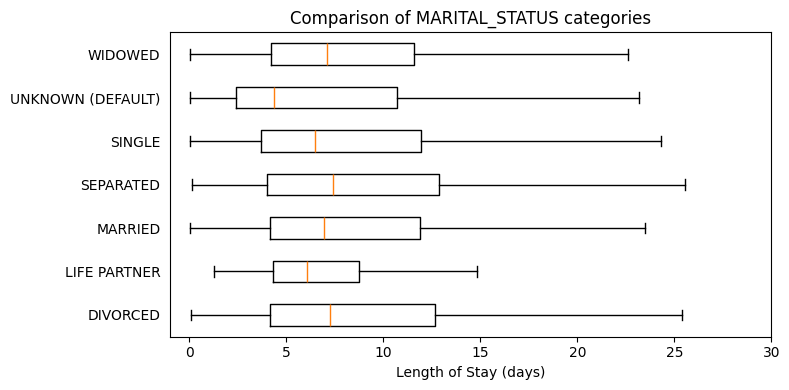

In [45]:
boxplot_los_groupby('MARITAL_STATUS')

**Feature Engineering: DIAGNOSES_ICD Table**

In [46]:
df_diagcode.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 651047 entries, 0 to 651046
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   ROW_ID      651047 non-null  Int64 
 1   SUBJECT_ID  651047 non-null  Int64 
 2   HADM_ID     651047 non-null  Int64 
 3   SEQ_NUM     651000 non-null  Int64 
 4   ICD9_CODE   651000 non-null  object
dtypes: Int64(4), object(1)
memory usage: 27.3+ MB


In [47]:
print('There are {} unique ICD9 codes in this dataset.'.format(df_diagcode['ICD9_CODE'].value_counts().count()))

There are 6984 unique ICD9 codes in this dataset.


In [48]:
df_diagcode.head()

,ROW_ID,SUBJECT_ID,HADM_ID,SEQ_NUM,ICD9_CODE
0,3113,256,108811,1,53240
1,3114,256,108811,2,41071
2,3115,256,108811,3,53560
3,3116,256,108811,4,40390
4,3117,256,108811,5,5859


In [49]:
# Filter out E and V codes since processing will be done on the numeric first 3 values
df_diagcode['recode'] = df_diagcode['ICD9_CODE'].astype(str)
mask = ~df_diagcode['recode'].str.contains("[a-zA-Z]", na=False)
df_diagcode['recode'] = df_diagcode['recode'].where(mask, '999')

In [50]:
# https://stackoverflow.com/questions/46168450/replace-specific-range-of-values-in-data-frame-pandas
df_diagcode['recode'] = df_diagcode['recode'].str.slice(start=0, stop=3, step=1)
df_diagcode['recode'] = df_diagcode['recode'].astype(int)

In [51]:
list(df_diagcode)

['ROW_ID', 'SUBJECT_ID', 'HADM_ID', 'SEQ_NUM', 'ICD9_CODE', 'recode']

In [52]:
df_diagcode.head()


,ROW_ID,SUBJECT_ID,HADM_ID,SEQ_NUM,ICD9_CODE,recode
0,3113,256,108811,1,53240,532
1,3114,256,108811,2,41071,410
2,3115,256,108811,3,53560,535
3,3116,256,108811,4,40390,403
4,3117,256,108811,5,5859,585


In [53]:
# ICD-9 Main Category ranges
icd9_ranges = [(1, 140), (140, 240), (240, 280), (280, 290), (290, 320), (320, 390),
               (390, 460), (460, 520), (520, 580), (580, 630), (630, 680), (680, 710),
               (710, 740), (740, 760), (760, 780), (780, 800), (800, 1000), (1000, 2000)]

# Associated category names
diag_dict = {0: 'infectious', 1: 'neoplasms', 2: 'endocrine', 3: 'blood',
             4: 'mental', 5: 'nervous', 6: 'circulatory', 7: 'respiratory',
             8: 'digestive', 9: 'genitourinary', 10: 'pregnancy', 11: 'skin',
             12: 'muscular', 13: 'congenital', 14: 'prenatal', 15: 'misc',
             16: 'injury', 17: 'misc'}

# Re-code in terms of integer
for num, cat_range in enumerate(icd9_ranges):
    df_diagcode['recode'] = np.where(df_diagcode['recode'].between(cat_range[0],cat_range[1]),
            num, df_diagcode['recode'])

# Convert integer to category name using diag_dict
df_diagcode['recode'] = df_diagcode['recode']
df_diagcode['cat'] = df_diagcode['recode'].replace(diag_dict)

In [54]:
# Verify
df_diagcode.head()

,ROW_ID,SUBJECT_ID,HADM_ID,SEQ_NUM,ICD9_CODE,recode,cat
0,3113,256,108811,1,53240,8,digestive
1,3114,256,108811,2,41071,6,circulatory
2,3115,256,108811,3,53560,8,digestive
3,3116,256,108811,4,40390,6,circulatory
4,3117,256,108811,5,5859,9,genitourinary


In [55]:
# Filter out E and V codes since processing will be done on the numeric first 3 values
df_diagcode['recode'] = df_diagcode['ICD9_CODE']
mask = ~df_diagcode['recode'].str.contains("[a-zA-Z]", na=False)
df_diagcode['recode'] = df_diagcode['recode'][mask]
df_diagcode['recode'] = df_diagcode['recode'].fillna('999')
df_diagcode['recode'] = df_diagcode['recode'].str.slice(start=0, stop=3, step=1)
df_diagcode['recode'] = df_diagcode['recode'].astype(int)

# ICD-9 Main Category ranges
icd9_ranges = [(1, 140), (140, 240), (240, 280), (280, 290), (290, 320), (320, 390),
               (390, 460), (460, 520), (520, 580), (580, 630), (630, 680), (680, 710),
               (710, 740), (740, 760), (760, 780), (780, 800), (800, 1000), (1000, 2000)]

# Associated category names
diag_dict = {0: 'infectious', 1: 'neoplasms', 2: 'endocrine', 3: 'blood',
             4: 'mental', 5: 'nervous', 6: 'circulatory', 7: 'respiratory',
             8: 'digestive', 9: 'genitourinary', 10: 'pregnancy', 11: 'skin',
             12: 'muscular', 13: 'congenital', 14: 'prenatal', 15: 'misc',
             16: 'injury', 17: 'misc'}

# Re-code in terms of integer
for num, cat_range in enumerate(icd9_ranges):
    df_diagcode['recode'] = np.where(df_diagcode['recode'].between(cat_range[0], cat_range[1]),
                                     num, df_diagcode['recode'])

# Convert integer to category name using diag_dict
df_diagcode['recode'] = df_diagcode['recode']
df_diagcode['cat'] = df_diagcode['recode'].replace(diag_dict)

# Verify
print(df_diagcode.head())

   ROW_ID  SUBJECT_ID  HADM_ID  SEQ_NUM ICD9_CODE  recode            cat
0    3113         256   108811        1     53240       8      digestive
1    3114         256   108811        2     41071       6    circulatory
2    3115         256   108811        3     53560       8      digestive
3    3116         256   108811        4     40390       6    circulatory
4    3117         256   108811        5      5859       9  genitourinary


In [56]:
# Create list of diagnoses for each admission
hadm_list = df_diagcode.groupby('HADM_ID')['cat'].apply(list).reset_index()
hadm_list.head()

,HADM_ID,cat
0,100001,"[endocrine, nervous, genitourinary, digestive,..."
1,100003,"[digestive, blood, infectious, digestive, circ..."
2,100006,"[respiratory, respiratory, respiratory, neopla..."
3,100007,"[digestive, digestive, injury, respiratory, ci..."
4,100009,"[circulatory, injury, circulatory, endocrine, ..."


In [57]:
# Convert diagnoses list into hospital admission-item matrix
hadm_item = pd.get_dummies(hadm_list['cat'].apply(pd.Series).stack()).groupby(level=0).sum()
hadm_item.head()

,blood,circulatory,congenital,digestive,endocrine,genitourinary,infectious,injury,mental,misc,muscular,neoplasms,nervous,pregnancy,prenatal,respiratory,skin
0,0,2,0,2,5,2,0,2,0,0,0,0,2,0,0,0,1
1,1,2,0,4,0,0,1,0,0,1,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,2,1,1,0,1,0,0,0,3,0
3,0,1,0,2,0,0,0,1,0,0,0,0,0,0,0,1,0
4,1,7,0,0,3,0,0,7,0,0,0,0,0,0,0,0,0


In [58]:
# Join back with HADM_ID, will merge with main admissions DF later
hadm_item = hadm_item.join(hadm_list['HADM_ID'], how="outer")
hadm_item.head()

,blood,circulatory,congenital,digestive,endocrine,genitourinary,infectious,injury,mental,misc,muscular,neoplasms,nervous,pregnancy,prenatal,respiratory,skin,HADM_ID
0,0,2,0,2,5,2,0,2,0,0,0,0,2,0,0,0,1,100001
1,1,2,0,4,0,0,1,0,0,1,0,0,0,0,0,0,0,100003
2,0,0,0,0,1,0,0,2,1,1,0,1,0,0,0,3,0,100006
3,0,1,0,2,0,0,0,1,0,0,0,0,0,0,0,1,0,100007
4,1,7,0,0,3,0,0,7,0,0,0,0,0,0,0,0,0,100009


In [59]:
# Merge with main admissions df
df = df.merge(hadm_item, how='inner', on='HADM_ID')

In [60]:
# Verify Merge
df.head()

,SUBJECT_ID,HADM_ID,ADMITTIME,DEATHTIME,ADMISSION_TYPE,ADMISSION_LOCATION,DISCHARGE_LOCATION,INSURANCE,LANGUAGE,RELIGION,...,injury,mental,misc,muscular,neoplasms,nervous,pregnancy,prenatal,respiratory,skin
0,3115,134067,2139-02-13 03:11:00,NaT,EMERGENCY,EMERGENCY ROOM ADMIT,SNF,Medicare,None,NOT RELIGIOUS,...,3,1,0,0,0,0,0,0,0,0
1,7124,109129,2188-07-11 00:58:00,NaT,EMERGENCY,EMERGENCY ROOM ADMIT,SNF,Medicare,None,NOT RELIGIOUS,...,1,0,0,0,0,1,0,0,2,1
2,10348,121510,2133-04-16 21:12:00,NaT,EMERGENCY,EMERGENCY ROOM ADMIT,SNF,Medicare,None,NOT RELIGIOUS,...,2,1,0,0,0,3,0,0,1,0
3,9396,106469,2109-02-16 23:14:00,NaT,EMERGENCY,EMERGENCY ROOM ADMIT,SNF,Medicare,None,NOT RELIGIOUS,...,3,1,0,1,0,0,0,0,0,0
4,9333,133732,2167-10-06 18:35:00,NaT,URGENT,TRANSFER FROM HOSP/EXTRAM,SNF,Private,None,NOT RELIGIOUS,...,0,0,0,0,0,0,0,0,0,0


Text(0.5, 1.0, 'Comparison of Diagnoses')

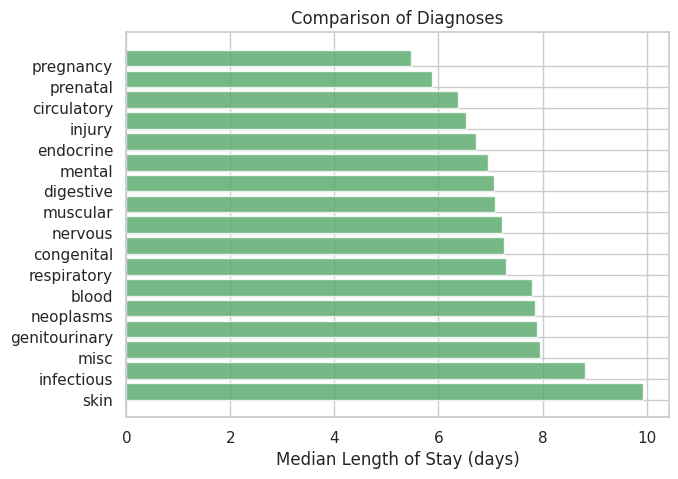

In [61]:
# Look at the median LOS by diagnosis category
diag_cat_list = ['skin', 'infectious',  'misc', 'genitourinary', 'neoplasms', 'blood', 'respiratory',
                  'congenital','nervous', 'muscular', 'digestive', 'mental', 'endocrine', 'injury',
                 'circulatory', 'prenatal',  'pregnancy']

results = []
for variable in diag_cat_list:
    results.append(df[[variable, 'LOS']].groupby(variable).median().reset_index().values[1][1])

sns.set(style="whitegrid")
#sns.set_style("ticks")
fig, ax = plt.subplots(figsize=(7,5))
ind = range(len(results))
ax.barh(ind, results, align='edge', color = '#55a868', alpha=0.8)
ax.set_yticks(ind)
ax.set_yticklabels(diag_cat_list)
ax.set_xlabel('Median Length of Stay (days)')
ax.tick_params(left=False, right=False, top=False)
ax.set_title('Comparison of Diagnoses'.format(variable))

**Feature Engineering: Patients Table**

In [ ]:
df_pat = pd.read_csv(path_patients)

In [62]:
df_pat.head()

,ROW_ID,SUBJECT_ID,GENDER,DOB,DOD,DOD_HOSP,DOD_SSN,EXPIRE_FLAG
0,49,56,F,1804-01-02,2104-01-08,2104-01-08,2104-01-08,1
1,17808,18848,F,2042-08-21,2128-01-08,2128-01-08,2128-01-08,1
2,36390,61056,F,2067-04-11,2152-01-08,2152-01-08,2152-01-08,1
3,25371,26889,F,2115-11-04,2164-01-08,2164-01-08,2164-01-08,1
4,17328,18333,F,2094-01-21,2168-01-08,2168-01-08,2168-01-08,1


In [63]:
df_pat['GENDER'].value_counts()

,count
GENDER,
M,26121
F,20399


In [64]:
# Convert to datetime type
df_pat['DOB'] = pd.to_datetime(df_pat['DOB'])

In [65]:
df_pat = df_pat[['SUBJECT_ID', 'DOB', 'GENDER']]
df_pat.head()

,SUBJECT_ID,DOB,GENDER
0,56,1804-01-02,F
1,18848,2042-08-21,F
2,61056,2067-04-11,F
3,26889,2115-11-04,F
4,18333,2094-01-21,F


In [66]:
df = df.merge(df_pat, how='inner', on='SUBJECT_ID')

In [67]:
df.head()


,SUBJECT_ID,HADM_ID,ADMITTIME,DEATHTIME,ADMISSION_TYPE,ADMISSION_LOCATION,DISCHARGE_LOCATION,INSURANCE,LANGUAGE,RELIGION,...,misc,muscular,neoplasms,nervous,pregnancy,prenatal,respiratory,skin,DOB,GENDER
0,3115,134067,2139-02-13 03:11:00,NaT,EMERGENCY,EMERGENCY ROOM ADMIT,SNF,Medicare,None,NOT RELIGIOUS,...,0,0,0,0,0,0,0,0,2096-06-07,M
1,7124,109129,2188-07-11 00:58:00,NaT,EMERGENCY,EMERGENCY ROOM ADMIT,SNF,Medicare,None,NOT RELIGIOUS,...,0,0,0,1,0,0,2,1,2135-11-25,M
2,10348,121510,2133-04-16 21:12:00,NaT,EMERGENCY,EMERGENCY ROOM ADMIT,SNF,Medicare,None,NOT RELIGIOUS,...,0,0,0,3,0,0,1,0,2049-06-08,F
3,9396,106469,2109-02-16 23:14:00,NaT,EMERGENCY,EMERGENCY ROOM ADMIT,SNF,Medicare,None,NOT RELIGIOUS,...,0,1,0,0,0,0,0,0,1809-02-16,M
4,9333,133732,2167-10-06 18:35:00,NaT,URGENT,TRANSFER FROM HOSP/EXTRAM,SNF,Private,None,NOT RELIGIOUS,...,0,0,0,0,0,0,0,0,2107-03-10,F


In [68]:
# Find the first admission time for each patient
df_age_min = df[['SUBJECT_ID', 'ADMITTIME']].groupby('SUBJECT_ID').min().reset_index()
df_age_min.columns = ['SUBJECT_ID', 'ADMIT_MIN']
df_age_min.head()

,SUBJECT_ID,ADMIT_MIN
0,2,2138-07-17 19:04:00
1,3,2101-10-20 19:08:00
2,4,2191-03-16 00:28:00
3,5,2103-02-02 04:31:00
4,6,2175-05-30 07:15:00


In [69]:
df = df.merge(df_age_min, how='outer', on='SUBJECT_ID')

In [70]:
# Verify merge
df.head()

,SUBJECT_ID,HADM_ID,ADMITTIME,DEATHTIME,ADMISSION_TYPE,ADMISSION_LOCATION,DISCHARGE_LOCATION,INSURANCE,LANGUAGE,RELIGION,...,muscular,neoplasms,nervous,pregnancy,prenatal,respiratory,skin,DOB,GENDER,ADMIT_MIN
0,2,163353,2138-07-17 19:04:00,NaT,NEWBORN,PHYS REFERRAL/NORMAL DELI,HOME,Private,None,NOT SPECIFIED,...,0,0,0,0,0,0,0,2138-07-17,M,2138-07-17 19:04:00
1,3,145834,2101-10-20 19:08:00,NaT,EMERGENCY,EMERGENCY ROOM ADMIT,SNF,Medicare,None,NOT RELIGIOUS,...,0,0,0,0,0,0,1,2025-04-11,M,2101-10-20 19:08:00
2,4,185777,2191-03-16 00:28:00,NaT,EMERGENCY,EMERGENCY ROOM ADMIT,HOME WITH HOME IV PROVIDR,Private,None,NOT RELIGIOUS,...,0,0,0,0,0,0,0,2143-05-12,F,2191-03-16 00:28:00
3,5,178980,2103-02-02 04:31:00,NaT,NEWBORN,PHYS REFERRAL/NORMAL DELI,HOME,Private,None,NOT RELIGIOUS,...,0,0,0,0,0,0,0,2103-02-02,M,2103-02-02 04:31:00
4,6,107064,2175-05-30 07:15:00,NaT,ELECTIVE,PHYS REFERRAL/NORMAL DELI,HOME HEALTH CARE,Medicare,ENGL,NOT SPECIFIED,...,0,0,0,0,0,0,0,2109-06-21,F,2175-05-30 07:15:00


In [71]:
df['ADMIT_MIN'] = pd.to_datetime(df['ADMIT_MIN']).dt.date
df['DOB'] = pd.to_datetime(df['DOB']).dt.date
df['age'] = df.apply(lambda e: (e['ADMIT_MIN'] - e['DOB']).days/365, axis=1)

#df['ADMIT_MIN'] = pd.to_datetime(df['ADMIT_MIN'])
#df['DOB'] = pd.to_datetime(df['DOB'])
#df['age'] = (df['ADMIT_MIN'].sub(df['DOB'], axis=0))// np.timedelta64(1, 'Y')
#df['age'].isnull().sum()
df.head()

,SUBJECT_ID,HADM_ID,ADMITTIME,DEATHTIME,ADMISSION_TYPE,ADMISSION_LOCATION,DISCHARGE_LOCATION,INSURANCE,LANGUAGE,RELIGION,...,neoplasms,nervous,pregnancy,prenatal,respiratory,skin,DOB,GENDER,ADMIT_MIN,age
0,2,163353,2138-07-17 19:04:00,NaT,NEWBORN,PHYS REFERRAL/NORMAL DELI,HOME,Private,None,NOT SPECIFIED,...,0,0,0,0,0,0,2138-07-17,M,2138-07-17,0.000000
1,3,145834,2101-10-20 19:08:00,NaT,EMERGENCY,EMERGENCY ROOM ADMIT,SNF,Medicare,None,NOT RELIGIOUS,...,0,0,0,0,0,1,2025-04-11,M,2101-10-20,76.575342
2,4,185777,2191-03-16 00:28:00,NaT,EMERGENCY,EMERGENCY ROOM ADMIT,HOME WITH HOME IV PROVIDR,Private,None,NOT RELIGIOUS,...,0,0,0,0,0,0,2143-05-12,F,2191-03-16,47.876712
3,5,178980,2103-02-02 04:31:00,NaT,NEWBORN,PHYS REFERRAL/NORMAL DELI,HOME,Private,None,NOT RELIGIOUS,...,0,0,0,0,0,0,2103-02-02,M,2103-02-02,0.000000
4,6,107064,2175-05-30 07:15:00,NaT,ELECTIVE,PHYS REFERRAL/NORMAL DELI,HOME HEALTH CARE,Medicare,ENGL,NOT SPECIFIED,...,0,0,0,0,0,0,2109-06-21,F,2175-05-30,65.983562


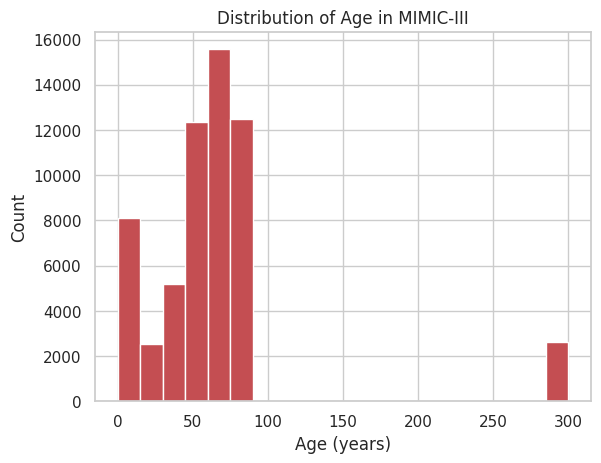

In [72]:
# Note that no ‘middle’ patients show up - this reflects the fact that MIMIC-III does not contain data from pediatric patients.
plt.hist(df['age'], bins=20, color='#c44e52')
plt.ylabel('Count')
plt.xlabel('Age (years)')
plt.title('Distribution of Age in MIMIC-III')
plt.tick_params(left=False, bottom=False, top=False, right=False)
plt.show();

(1.0, 50.0)

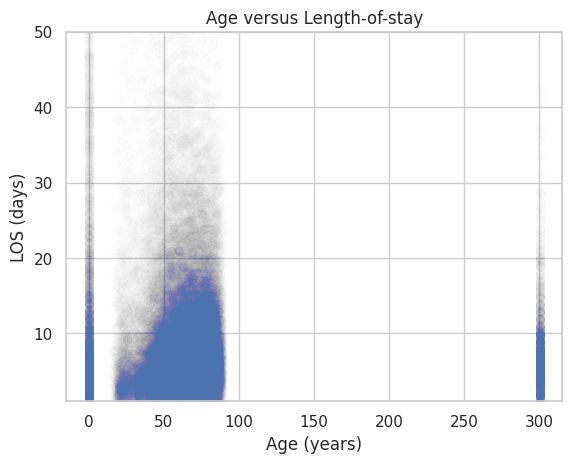

In [73]:
plt.scatter(df['age'], df['LOS'], alpha=0.005)
#plt.yscale('sqrt')
plt.ylabel('LOS (days)')
plt.xlabel('Age (years)')
plt.title('Age versus Length-of-stay')
plt.ylim(1, 50)

In [74]:
# https://en.wikipedia.org/wiki/List_of_ICD-9_codes
age_ranges = [(0, 13), (13, 36), (36, 56), (56, 100)]
for num, cat_range in enumerate(age_ranges):
    df['age'] = np.where(df['age'].between(cat_range[0],cat_range[1]),
            num, df['age'])

age_dict = {0: 'newborn', 1: 'young_adult', 2: 'middle_adult', 3: 'senior'}
df['age'] = df['age'].replace(age_dict)
df.age.value_counts()

,count
age,
senior,32091
middle_adult,12077
newborn,8101
young_adult,3999
300.2,2610


/tmp/ipython-input-33-1364745201.py:36: MatplotlibDeprecationWarning: Passing the notch parameter of boxplot() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  ax.boxplot(hist_data, 0, '', vert=False)


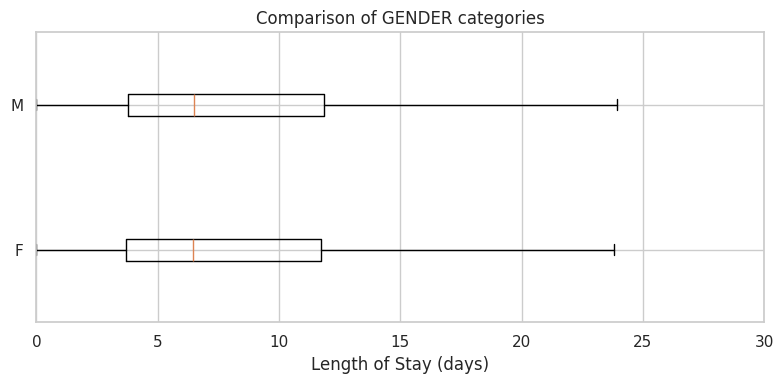

/tmp/ipython-input-75-1927360022.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'GENDER': {'M': 0, 'F':1}}, inplace=True)


In [75]:
boxplot_los_groupby('GENDER', los_range=(0, 30))
df.replace({'GENDER': {'M': 0, 'F':1}}, inplace=True)

**Feature Engineering: ICUSTAYS Table**

In [77]:
# Intensive Care Unit (ICU) for each admission to hospital
df_icu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61532 entries, 0 to 61531
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ROW_ID          61532 non-null  Int64         
 1   SUBJECT_ID      61532 non-null  Int64         
 2   HADM_ID         61532 non-null  Int64         
 3   ICUSTAY_ID      61532 non-null  Int64         
 4   DBSOURCE        61532 non-null  object        
 5   FIRST_CAREUNIT  61532 non-null  object        
 6   LAST_CAREUNIT   61532 non-null  object        
 7   FIRST_WARDID    61532 non-null  Int64         
 8   LAST_WARDID     61532 non-null  Int64         
 9   INTIME          61532 non-null  datetime64[us]
 10  OUTTIME         61522 non-null  datetime64[us]
 11  LOS             61522 non-null  float64       
dtypes: Int64(6), datetime64[us](2), float64(1), object(3)
memory usage: 6.0+ MB


In [78]:
df_icu['HADM_ID'].nunique()

57786

In [79]:
df_icu.groupby('FIRST_CAREUNIT').median(numeric_only=True)

,ROW_ID,SUBJECT_ID,HADM_ID,ICUSTAY_ID,FIRST_WARDID,LAST_WARDID,LOS
FIRST_CAREUNIT,,,,,,,
CCU,29091.5,22964.5,150074.5,249373.5,7.0,7.0,2.19775
CSRU,31002.5,24488.0,150225.0,250492.0,14.0,14.0,2.15290
MICU,33612.5,26489.5,150368.0,250524.0,50.0,50.0,2.09550
NICU,19581.5,15456.5,149206.5,249308.0,56.0,56.0,0.80250
SICU,38089.0,30084.0,149744.0,248649.0,33.0,33.0,2.25220
TSICU,36382.0,28716.0,148915.0,250685.0,14.0,14.0,2.11150


In [81]:
# Based on above statistics, reduce to just ICU and NICU groups
df_icu['FIRST_CAREUNIT'].replace({'CCU': 'ICU', 'CSRU': 'ICU', 'MICU': 'ICU',
                                  'SICU': 'ICU', 'TSICU': 'ICU'}, inplace=True)

In [82]:
df_icu['cat'] = df_icu['FIRST_CAREUNIT']
icu_list = df_icu.groupby('HADM_ID')['cat'].apply(list).reset_index()
icu_list.head()

,HADM_ID,cat
0,100001,[ICU]
1,100003,[ICU]
2,100006,[ICU]
3,100007,[ICU]
4,100009,[ICU]


In [83]:
df_icu['FIRST_CAREUNIT'].value_counts()

,count
FIRST_CAREUNIT,
ICU,53432
NICU,8100


In [84]:
# Create admission-ICU matrix
icu_item = pd.get_dummies(icu_list['cat'].apply(pd.Series).stack()).groupby(level=0).sum()
icu_item[icu_item >= 1] = 1
icu_item = icu_item.join(icu_list['HADM_ID'], how="outer")
icu_item.head()

,ICU,NICU,HADM_ID
0,1,0,100001
1,1,0,100003
2,1,0,100006
3,1,0,100007
4,1,0,100009


In [85]:

print("Number of admissions to ICU {}.".format(icu_item.ICU.sum()))
print("Number of admissions to NICU {}.".format(icu_item.NICU.sum()))

Number of admissions to ICU 49794.
Number of admissions to NICU 7992.


In [86]:
# Merge ICU data with main dataFrame
df = df.merge(icu_item, how='outer', on='HADM_ID')

In [87]:
df.head()

,SUBJECT_ID,HADM_ID,ADMITTIME,DEATHTIME,ADMISSION_TYPE,ADMISSION_LOCATION,DISCHARGE_LOCATION,INSURANCE,LANGUAGE,RELIGION,...,pregnancy,prenatal,respiratory,skin,DOB,GENDER,ADMIT_MIN,age,ICU,NICU
0,58526,100001,2117-09-11 11:46:00,NaT,EMERGENCY,CLINIC REFERRAL/PREMATURE,HOME,Private,ENGL,NOT RELIGIOUS,...,0.0,0.0,0.0,1.0,2082-03-21,1.0,2117-09-11,young_adult,1.0,0.0
1,54610,100003,2150-04-17 15:34:00,NaT,EMERGENCY,EMERGENCY ROOM ADMIT,HOME,Private,ENGL,NOT SPECIFIED,...,0.0,0.0,0.0,0.0,2090-05-19,0.0,2150-04-17,senior,1.0,0.0
2,9895,100006,2108-04-06 15:49:00,NaT,EMERGENCY,EMERGENCY ROOM ADMIT,HOME,Private,None,NOT SPECIFIED,...,0.0,0.0,3.0,0.0,2059-05-07,1.0,2108-04-06,middle_adult,1.0,0.0
3,23018,100007,2145-03-31 05:33:00,NaT,EMERGENCY,EMERGENCY ROOM ADMIT,HOME,Private,None,NOT RELIGIOUS,...,0.0,0.0,1.0,0.0,2071-06-04,1.0,2145-03-31,senior,1.0,0.0
4,533,100009,2162-05-16 15:56:00,NaT,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,HOME HEALTH CARE,Private,None,NOT RELIGIOUS,...,0.0,0.0,0.0,0.0,2101-07-30,0.0,2162-05-16,senior,1.0,0.0


In [88]:
# Replace NaNs with 0
df['ICU'] = df['ICU'].fillna(0)
df['NICU'] = df['NICU'].fillna(0)

In [89]:

# Verify NaN fix
print(df.ICU.value_counts(dropna=False))
print(df.NICU.value_counts(dropna=False))

ICU
1.0    49794
0.0     9168
Name: count, dtype: int64
NICU
0.0    50970
1.0     7992
Name: count, dtype: int64


**Data Cleaning and Data Splitting**

In [90]:
# Look at what is no longer needed in the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58962 entries, 0 to 58961
Data columns (total 38 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   SUBJECT_ID          58878 non-null  Int64         
 1   HADM_ID             58962 non-null  Int64         
 2   ADMITTIME           58878 non-null  datetime64[us]
 3   DEATHTIME           5774 non-null   datetime64[us]
 4   ADMISSION_TYPE      58878 non-null  object        
 5   ADMISSION_LOCATION  58878 non-null  object        
 6   DISCHARGE_LOCATION  58878 non-null  object        
 7   INSURANCE           58878 non-null  object        
 8   LANGUAGE            33606 non-null  object        
 9   RELIGION            58878 non-null  object        
 10  MARITAL_STATUS      58878 non-null  object        
 11  ETHNICITY           58878 non-null  object        
 12  DIAGNOSIS           58853 non-null  object        
 13  LOS                 58878 non-null  float64   

In [92]:
# Remove deceased persons as they will skew LOS result
df = df[df['DECEASED'] == 0]

# Remove LOS with negative number, likely entry form error
df = df[df['LOS'] > 0]

In [93]:
# Drop unused or no longer needed columns
df.drop(columns=['SUBJECT_ID', 'HADM_ID', 'ADMITTIME', 'ADMISSION_LOCATION',
                'DISCHARGE_LOCATION', 'LANGUAGE', 'ADMIT_MIN', 'DOB',
                'DIAGNOSIS', 'DECEASED',  'DEATHTIME'], inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53104 entries, 0 to 58961
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ADMISSION_TYPE  53104 non-null  object 
 1   INSURANCE       53104 non-null  object 
 2   RELIGION        53104 non-null  object 
 3   MARITAL_STATUS  53104 non-null  object 
 4   ETHNICITY       53104 non-null  object 
 5   LOS             53104 non-null  float64
 6   blood           53104 non-null  float64
 7   circulatory     53104 non-null  float64
 8   congenital      53104 non-null  float64
 9   digestive       53104 non-null  float64
 10  endocrine       53104 non-null  float64
 11  genitourinary   53104 non-null  float64
 12  infectious      53104 non-null  float64
 13  injury          53104 non-null  float64
 14  mental          53104 non-null  float64
 15  misc            53104 non-null  float64
 16  muscular        53104 non-null  float64
 17  neoplasms       53104 non-null  floa

In [95]:
df.head()

,ADMISSION_TYPE,INSURANCE,RELIGION,MARITAL_STATUS,ETHNICITY,LOS,blood,circulatory,congenital,digestive,...,neoplasms,nervous,pregnancy,prenatal,respiratory,skin,GENDER,age,ICU,NICU
0,EMERGENCY,Private,NOT RELIGIOUS,DIVORCED,WHITE,6.207639,0.0,2.0,0.0,2.0,...,0.0,2.0,0.0,0.0,0.0,1.0,1.0,young_adult,1.0,0.0
1,EMERGENCY,Private,NOT SPECIFIED,SINGLE,WHITE,4.080556,1.0,2.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,senior,1.0,0.0
2,EMERGENCY,Private,NOT SPECIFIED,SINGLE,BLACK/AFRICAN AMERICAN,12.061806,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,3.0,0.0,1.0,middle_adult,1.0,0.0
3,EMERGENCY,Private,NOT RELIGIOUS,MARRIED,WHITE,7.296528,0.0,1.0,0.0,2.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,senior,1.0,0.0
4,EMERGENCY,Private,NOT RELIGIOUS,MARRIED,WHITE,4.903472,1.0,7.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,senior,1.0,0.0


In [96]:
# Create dummy columns for categorical variables
prefix_cols = ['ADM', 'INS', 'REL', 'ETH', 'AGE', 'MAR', 'RELIGION']
dummy_cols = ['ADMISSION_TYPE', 'INSURANCE', 'RELIGION',
             'ETHNICITY', 'age', 'MARITAL_STATUS', 'RELIGION']
df = pd.get_dummies(df, prefix=prefix_cols, columns=dummy_cols)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53104 entries, 0 to 58961
Data columns (total 51 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   LOS                         53104 non-null  float64
 1   blood                       53104 non-null  float64
 2   circulatory                 53104 non-null  float64
 3   congenital                  53104 non-null  float64
 4   digestive                   53104 non-null  float64
 5   endocrine                   53104 non-null  float64
 6   genitourinary               53104 non-null  float64
 7   infectious                  53104 non-null  float64
 8   injury                      53104 non-null  float64
 9   mental                      53104 non-null  float64
 10  misc                        53104 non-null  float64
 11  muscular                    53104 non-null  float64
 12  neoplasms                   53104 non-null  float64
 13  nervous                     53104 no

In [97]:
# Verify
df.head()

,LOS,blood,circulatory,congenital,digestive,endocrine,genitourinary,infectious,injury,mental,...,AGE_young_adult,MAR_DIVORCED,MAR_LIFE PARTNER,MAR_MARRIED,MAR_SEPARATED,MAR_SINGLE,MAR_UNKNOWN (DEFAULT),MAR_WIDOWED,RELIGION_NOT RELIGIOUS,RELIGION_NOT SPECIFIED
0,6.207639,0.0,2.0,0.0,2.0,5.0,2.0,0.0,2.0,0.0,...,True,True,False,False,False,False,False,False,True,False
1,4.080556,1.0,2.0,0.0,4.0,0.0,0.0,1.0,0.0,0.0,...,False,False,False,False,False,True,False,False,False,True
2,12.061806,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,1.0,...,False,False,False,False,False,True,False,False,False,True
3,7.296528,0.0,1.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,...,False,False,False,True,False,False,False,False,True,False
4,4.903472,1.0,7.0,0.0,0.0,3.0,0.0,0.0,7.0,0.0,...,False,False,False,True,False,False,False,False,True,False


In [98]:
# Target Variable (Length-of-Stay)
LOS = df['LOS'].values
# Prediction Features
features = df.drop(columns=['LOS'])

In [99]:
features.head()

,blood,circulatory,congenital,digestive,endocrine,genitourinary,infectious,injury,mental,misc,...,AGE_young_adult,MAR_DIVORCED,MAR_LIFE PARTNER,MAR_MARRIED,MAR_SEPARATED,MAR_SINGLE,MAR_UNKNOWN (DEFAULT),MAR_WIDOWED,RELIGION_NOT RELIGIOUS,RELIGION_NOT SPECIFIED
0,0.0,2.0,0.0,2.0,5.0,2.0,0.0,2.0,0.0,0.0,...,True,True,False,False,False,False,False,False,True,False
1,1.0,2.0,0.0,4.0,0.0,0.0,1.0,0.0,0.0,1.0,...,False,False,False,False,False,True,False,False,False,True
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,1.0,1.0,...,False,False,False,False,False,True,False,False,False,True
3,0.0,1.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,...,False,False,False,True,False,False,False,False,True,False
4,1.0,7.0,0.0,0.0,3.0,0.0,0.0,7.0,0.0,0.0,...,False,False,False,True,False,False,False,False,True,False


In [100]:
# Split into train 80% and test 20%
X_train, X_test, y_train, y_test = train_test_split(features,
                                                    LOS,
                                                    test_size = .20,
                                                    random_state = 0)

# Show the results of the split
print("Training set has {} samples.".format(X_train.shape[0]))
print("Testing set has {} samples.".format(X_test.shape[0]))

Training set has 42483 samples.
Testing set has 10621 samples.


**Machine Learning Models**

In [101]:
# Regression models for comparison
models = [SGDRegressor(random_state = 0),
          GradientBoostingRegressor(random_state = 0),
          LinearRegression(),
          KNeighborsRegressor(),
          RandomForestRegressor(random_state = 0)]

results = {}

for model in models:

    # Instantiate and fit Regressor Model
    reg_model = model
    reg_model.fit(X_train, y_train)

    # Make predictions with model
    y_test_preds = reg_model.predict(X_test)

    # Grab model name and store results associated with model
    model_name = model.__class__.__name__
    results[model_name] = r2_score(y_test, y_test_preds)
    print(f'{model_name} done.')

SGDRegressor done.
GradientBoostingRegressor done.
LinearRegression done.
KNeighborsRegressor done.
RandomForestRegressor done.


Text(0.5, 1.0, 'Comparison of Regression Models')

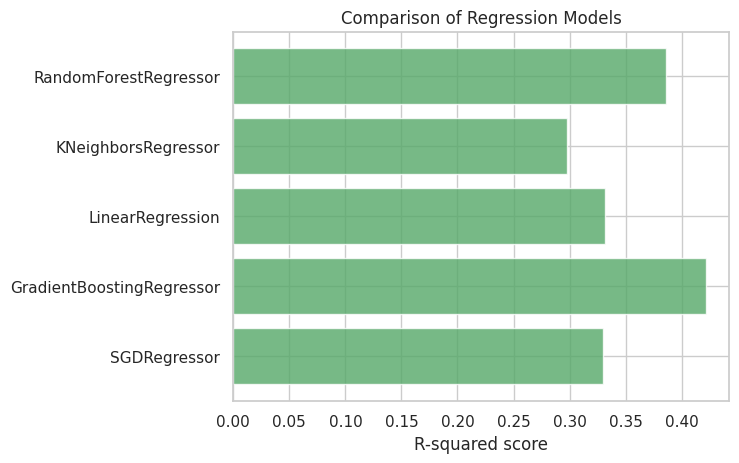

In [102]:
# R2 score results
fig, ax = plt.subplots()
ind = range(len(results))
ax.barh(ind, list(results.values()), align='center',
        color = '#55a868', alpha=0.8)
ax.set_yticks(ind)
ax.set_yticklabels(results.keys())
ax.set_xlabel('R-squared score')
ax.tick_params(left=False, top=False, right=False)
ax.set_title('Comparison of Regression Models')
#fig.savefig('images/compare_models.png', bbox_inches = 'tight')

In [103]:
# GradientBoostingRegressor will be used as the LOS prediction model
reg_model = GradientBoostingRegressor(random_state=0)
reg_model.fit(X_train, y_train)
y_test_preds = reg_model.predict(X_test)
r2_not_refined = r2_score(y_test, y_test_preds)
print(f"R2 score is: {r2_not_refined:2f}")

R2 score is: 0.421458


**Model Finetuning**

In [104]:
# Split into train 80% and test 20%
X_train, X_test, y_train, y_test = train_test_split(features,
                                                    LOS,
                                                    test_size = .20,
                                                    random_state = 42)

# Set the parameters by cross-validation
#tuned_parameters = [{'n_estimators': [100, 200, 300],
#                     'max_depth' : [2, 3, 4],
#                     'loss': ['ls', 'lad', 'huber']}]
tuned_parameters = [{'n_estimators': [200, 300],
                     'max_depth' : [3, 4],
                     'loss': ['squared_error', 'absolute_error']}]

# create and fit a ridge regression model, testing each alpha
reg_model = GradientBoostingRegressor()
grid = GridSearchCV(reg_model, tuned_parameters)
grid.fit(X_train, y_train)
reg_model_optimized = grid.best_estimator_

# summarize the results of the grid search
print(grid.best_score_)
print(grid.best_estimator_)

# >>5 minutes to run

KeyboardInterrupt: 

In [ ]:
#reg_model = GradientBoostingRegressor(n_estimators = 200, max_depth=4, random_state=0)
#reg_model.fit(X_train, y_train)
y_test_preds = reg_model_optimized.predict(X_test)
r2_optimized = r2_score(y_test, y_test_preds)
print(f"Optimized R2 score is: {r2_optimized:2f}")

In [ ]:
print(f'Model refinement improved R2 score by {r2_optimized-r2_not_refined:.4f}')

**Evaluation**

In [ ]:
# https://towardsdatascience.com/running-random-forests-inspect-the-feature-importances-with-this-code-2b00dd72b92e
feature_imp = pd.DataFrame(reg_model_optimized.feature_importances_,
                                   index = X_train.columns,
                                   columns=['importance']).sort_values('importance', ascending=False)

feature_imp.head(20)

,importance
prenatal,0.410410
respiratory,0.112580
infectious,0.105716
digestive,0.083970
nervous,0.082488
injury,0.034864
skin,0.019358
congenital,0.017490
endocrine,0.014756
circulatory,0.014590


In [ ]:
feature_imp.index[0:10].tolist()

['prenatal',
 'respiratory',
 'infectious',
 'digestive',
 'nervous',
 'injury',
 'skin',
 'congenital',
 'endocrine',
 'circulatory']

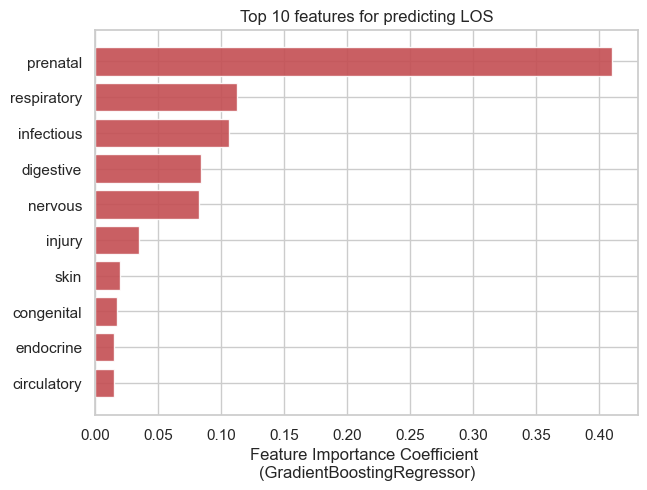

In [ ]:

# Plot feature importance
fig, ax = plt.subplots(figsize=(7, 5))
ind = range(0,10)
ax.barh(ind, feature_imp['importance'].values[0:10],
        align='center', color='#c44e52', alpha=0.9)
ax.set_yticks(ind)
ax.set_yticklabels(feature_imp.index[0:10].tolist())
ax.tick_params(left=False, top=False, right=False)
ax.set_title("Top 10 features for predicting LOS")
ax.set_xlabel('Feature Importance Coefficient \n(GradientBoostingRegressor)')
plt.gca().invert_yaxis()
#fig.savefig('images/feature_importance.png', bbox_inches = 'tight')

Prediction Model days 5.52885164147422
Median Model days 6.427673947839196
Average Model days 7.235765892517812
Prediction Model RMS 0.09262948131381642
Median Model RMS 0.12256797714023587
Average Model RMS 0.11751550834686907


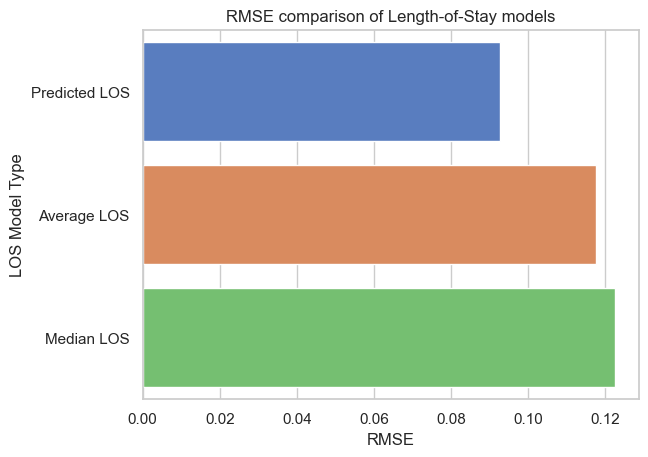

In [ ]:
actual_avg_los = df['LOS'].mean()
ml_count, md_count, avg_count = 0, 0, 0
ml_days, md_days, avg_days = 0, 0, 0
ml_days_rms, md_days_rms, avg_days_rms = 0, 0, 0

for i in range(y_test_preds.shape[0]):
    ml_model = abs(y_test_preds[i] - y_test[i])
    median_model = abs(actual_median_los - y_test[i])
    average_model = abs(actual_avg_los - y_test[i])

    ml_days += ml_model
    md_days += median_model
    avg_days += average_model

    ml_model_rms = (y_test_preds[i] - y_test[i]) ** 2
    median_model_rms = (actual_median_los - y_test[i]) ** 2
    average_model_rms = (actual_avg_los - y_test[i]) ** 2

    ml_days_rms += ml_model_rms
    md_days_rms += median_model_rms
    avg_days_rms += average_model_rms

print("Prediction Model days {}".format(ml_days / y_test_preds.shape[0]))
print("Median Model days {}".format(md_days / y_test_preds.shape[0]))
print("Average Model days {}".format(avg_days / y_test_preds.shape[0]))

print("Prediction Model RMS {}".format((ml_days_rms ** 0.5) / y_test_preds.shape[0]))
print("Median Model RMS {}".format((md_days_rms ** 0.5) / y_test_preds.shape[0]))
print("Average Model RMS {}".format((avg_days_rms ** 0.5) / y_test_preds.shape[0]))
# RMSE plot for writeup
data = pd.DataFrame({'RMSE': [(ml_days_rms**0.5)/y_test_preds.shape[0],
                             (avg_days_rms**0.5)/y_test_preds.shape[0],
                             (md_days_rms**0.5)/y_test_preds.shape[0]],
                     'LOS Model Type': ['Predicted LOS', 'Average LOS', 'Median LOS'] })

fig, ax = plt.subplots()
ax = sns.barplot(x='RMSE', y='LOS Model Type', data=data, palette='muted', hue='LOS Model Type', legend=False)
ax.set_title('RMSE comparison of Length-of-Stay models')
ax.tick_params(top=False, left=False, right=False)

plt.show()

> <small>*Notebook last updated by Joakim Nguyen on 3/9/2025*</small>